# 06 — Experimento de Ablação (Configurações A, B, C, D)

**Projeto:** Mão na Roda — Diagnóstico Automotivo via PLN e ML
**Equipe:** Diego Spagnuolo Sugai, Kauê Henrique Matias Alves, Leonardo Moreira dos Santos, Victor Maki Tarcha
**Orientador:** Prof. Dr. Ivan Carlos Alcântara de Oliveira

Este notebook executa o **experimento de ablação** que compara 4 configurações do pipeline, isolando a contribuição de cada componente. Resultado: tabela comparativa que vai direto ao relatório.

## As 4 configurações

| Config | Regras | BERTimbau | Canônica | RAG+LLM |
|--------|--------|-----------|----------|---------|
| **A**  | ❌     | ✅        | ✅       | ❌      |
| **B**  | ❌     | ✅        | ✅       | ✅      |
| **C**  | ✅     | ✅        | ✅       | ❌      |
| **D**  | ✅     | ✅        | ✅       | ✅ (pipeline completo) |

## Plano de execução

1. Setup e carregamento de artefatos (BERTimbau, ChromaDB, planilhas)
2. Funções de pipeline modulares
3. Avaliação no hold-out de teste (34 relatos)
4. Métricas: F1-macro, accuracy, latência média, cobertura
5. Tabela e gráfico comparativos
6. Análise qualitativa de erros

**Tempo estimado:** 15-25 minutos (a maior parte é o LLM em B e D).

---
## Seção 0 — Setup do ambiente

In [ ]:
# Mesmas pinagens dos notebooks anteriores
!pip install -q "numpy<2" "transformers>=4.40,<5.0" "chromadb>=0.5,<0.6" "sentence-transformers>=2.7,<4.0" "anthropic>=0.30" 2>&1 | tail -3
print('Dependências instaladas.')
print('Se for a primeira execução desta sessão, REINICIE A SESSÃO antes de continuar.')

tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
google-adk 1.29.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.41.1 which is incompatible.
google-adk 1.29.0 requires opentelemetry-sdk<1.39.0,>=1.36.0, but you have opentelemetry-sdk 1.41.1 which is incompatible.
Dependências instaladas.
Se for a primeira execução desta sessão, REINICIE A SESSÃO antes de continuar.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

BASE = Path('/content/drive/MyDrive/Agente Mecânico')

DATASET_PATH    = BASE / 'Dataset_Estruturado' / 'dataset_mao_na_roda_v2.xlsx'
BASE_CONHEC     = BASE / 'Dataset_Estruturado' / 'base_conhecimento_classes.xlsx'
PADROES_REDIR   = BASE / 'Dataset_Estruturado' / 'padroes_redirect.xlsx'
MODELO_DIR      = BASE / 'modelos' / 'bertimbau_mao_na_roda'
CHROMA_DIR      = BASE / 'chromadb'
RESULTADOS_DIR  = BASE / 'resultados'
SPLIT_TESTE     = RESULTADOS_DIR / 'split_teste.csv'

# Verificar todos os artefatos
for p, label in [
    (DATASET_PATH,   'Dataset principal'),
    (BASE_CONHEC,    'Base canônica'),
    (PADROES_REDIR,  'Padrões de redirect'),
    (MODELO_DIR,     'BERTimbau treinado'),
    (CHROMA_DIR,     'ChromaDB'),
    (SPLIT_TESTE,    'Split de teste'),
]:
    status = 'OK' if p.exists() else 'FALTANDO'
    print(f'[{status}] {label}: {p}')

[OK] Dataset principal: /content/drive/MyDrive/Agente Mecânico/Dataset_Estruturado/dataset_mao_na_roda_v2.xlsx
[OK] Base canônica: /content/drive/MyDrive/Agente Mecânico/Dataset_Estruturado/base_conhecimento_classes.xlsx
[OK] Padrões de redirect: /content/drive/MyDrive/Agente Mecânico/Dataset_Estruturado/padroes_redirect.xlsx
[OK] BERTimbau treinado: /content/drive/MyDrive/Agente Mecânico/modelos/bertimbau_mao_na_roda
[OK] ChromaDB: /content/drive/MyDrive/Agente Mecânico/chromadb
[OK] Split de teste: /content/drive/MyDrive/Agente Mecânico/resultados/split_teste.csv


In [ ]:
import torch
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Device: {torch.cuda.get_device_name(0)}')

CUDA: True
Device: Tesla T4


---
## Seção 1 — Carregar artefatos do projeto

- BERTimbau treinado da pasta `modelos/`
- Base canônica e padrões de redirect (planilhas)
- Coleção ChromaDB com 1946 chunks
- Conjunto de teste (mesmo split do fine-tuning)

In [ ]:
import pandas as pd

# Planilhas
df_base    = pd.read_excel(BASE_CONHEC)
df_redir   = pd.read_excel(PADROES_REDIR)
df_teste   = pd.read_csv(SPLIT_TESTE)

# Mapa de classes
CLASSES = (df_teste[['falha_label','falha_descricao']]
           .drop_duplicates().sort_values('falha_label')
           .set_index('falha_label')['falha_descricao'].to_dict())
N_CLASSES = len(CLASSES)

# Lookup rápido da base canônica por classe
base_por_classe = df_base.set_index('classe_id').to_dict('index')

print(f'Hold-out de teste: {len(df_teste)} relatos')
print(f'Classes: {N_CLASSES}')
print(f'Base canônica: {len(df_base)} entradas')
print(f'Padrões de redirect: {len(df_redir)}')

Hold-out de teste: 17 relatos
Classes: 10
Base canônica: 10 entradas
Padrões de redirect: 10


In [ ]:
# Carregar BERTimbau treinado
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print('Carregando BERTimbau treinado...')
tokenizer = AutoTokenizer.from_pretrained(str(MODELO_DIR))
modelo_bert = AutoModelForSequenceClassification.from_pretrained(str(MODELO_DIR))
modelo_bert.eval()
if torch.cuda.is_available():
    modelo_bert = modelo_bert.cuda()
print(f'Carregado: {sum(p.numel() for p in modelo_bert.parameters())/1e6:.1f}M parâmetros')

Carregando BERTimbau treinado...
Carregado: 108.9M parâmetros


In [ ]:
# Carregar ChromaDB
import chromadb
from sentence_transformers import SentenceTransformer

print('Carregando ChromaDB...')
client = chromadb.PersistentClient(path=str(CHROMA_DIR))
colecao = client.get_collection('mao_na_roda_manuais')
print(f'Coleção carregada: {colecao.count()} chunks')

print('\nCarregando modelo de embedding (bge-m3)...')
modelo_emb = SentenceTransformer('BAAI/bge-m3')
print(f'Embedding pronto.')

Carregando ChromaDB...


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


Coleção carregada: 1946 chunks

Carregando modelo de embedding (bge-m3)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Embedding pronto.


---
## Seção 2 — Funções modulares do pipeline

Cada função pode ser ligada/desligada nas configurações de ablação.

In [ ]:
# ── 2.1 Normalização (compartilhada com regras_redirect_v2) ────────────
import re
import unicodedata

def normalizar(texto):
    t = str(texto).lower().strip()
    t = unicodedata.normalize('NFD', t)
    t = ''.join(c for c in t if unicodedata.category(c) != 'Mn')
    return t

def keyword_presente(relato_norm, kw_pipe):
    if not kw_pipe or pd.isna(kw_pipe): return False
    for kw in str(kw_pipe).split('|'):
        kw_norm = normalizar(kw.strip())
        if not kw_norm: continue
        padrao = r'\b' + re.escape(kw_norm) + r'\b'
        if re.search(padrao, relato_norm):
            return True
    return False

In [ ]:
# ── 2.2 Motor de regras (mesmo do notebook integrado) ──────────────────
def avaliar_regras(relato, df_regras):
    relato_norm = normalizar(relato)
    for _, regra in df_regras.iterrows():
        if regra.get('tipo_acao') == 'seguir_pipeline_rag':
            return None
        # Obrigatórias
        obrig = regra.get('keywords_obrigatorias', '')
        if obrig and not pd.isna(obrig):
            if not keyword_presente(relato_norm, obrig): continue
        # Contexto
        ctx = regra.get('keywords_contexto', '')
        if ctx and not pd.isna(ctx):
            if not keyword_presente(relato_norm, ctx): continue
        # Bloqueio
        bloq = regra.get('keywords_bloqueio', '')
        if bloq and not pd.isna(bloq):
            if keyword_presente(relato_norm, bloq): continue
        return regra
    return None

In [ ]:
# ── 2.3 Classificador BERTimbau ────────────────────────────────────────
import numpy as np

def classificar_bert(relato, top_k=3):
    """Devolve {classe_id, confianca, top_k_classes, probabilidades}."""
    inputs = tokenizer(relato, truncation=True, padding=True, max_length=128, return_tensors='pt')
    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}
    with torch.no_grad():
        outputs = modelo_bert(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)[0].cpu().numpy()
    classe_id = int(np.argmax(probs))
    return {
        'classe_id': classe_id,
        'classe_nome': CLASSES.get(classe_id, '?'),
        'confianca': float(probs[classe_id]),
        'probabilidades': probs.tolist(),
    }

In [ ]:
# ── 2.4 Resposta canônica (lookup + condição de keyword) ───────────────
LIMIAR_ALTA_CONF = 0.85

def tem_keyword_alta_conf(relato, classe_id):
    """Verifica se relato tem keyword da base canônica para a classe predita."""
    if classe_id not in base_por_classe: return False
    base = base_por_classe[classe_id]
    kws = base.get('keywords_alta_confianca', '')
    if pd.isna(kws) or not kws: return False
    return keyword_presente(normalizar(relato), kws)

def gerar_resposta_canonica(classe_id):
    base = base_por_classe.get(classe_id, {})
    return {
        'texto':  base.get('frase_resposta_canonica', '(sem resposta canônica para esta classe)'),
        'urgencia': base.get('urgencia_padrao', 'media'),
        'fonte':  'canonica',
    }

In [ ]:
# ── 2.5 RAG: recuperação de chunks ────────────────────────────────────
def recuperar_chunks(relato, classe_id=None, top_k=3):
    q_emb = modelo_emb.encode(relato, normalize_embeddings=True).tolist()
    where = None
    # Filtro: pelo menos um sistema mapeado (chunks técnicos, não capa/índice)
    where = {'tem_sistema': {'$eq': True}}
    res = colecao.query(query_embeddings=[q_emb], n_results=top_k, where=where)
    return [{
        'texto': res['documents'][0][i],
        'modelo': res['metadatas'][0][i].get('modelo'),
        'pagina': res['metadatas'][0][i].get('pagina'),
        'distancia': res['distances'][0][i],
    } for i in range(len(res['documents'][0]))]

In [ ]:
# ── 2.6 LLM gerador (Claude Haiku via Anthropic SDK) ──────────────────
# Modo MOCK ou REAL. Configure abaixo.
USAR_LLM_REAL = True  # Mude para False se não tiver chave de API

if USAR_LLM_REAL:
    from google.colab import userdata
    import anthropic
    try:
        api_key = userdata.get('ANTHROPIC_API_KEY')
        cliente_anthropic = anthropic.Anthropic(api_key=api_key)
        print('LLM REAL: Anthropic configurado.')
    except Exception as e:
        print(f'AVISO: chave ANTHROPIC_API_KEY não encontrada nos Secrets. Caindo para MOCK.')
        print('       Para usar LLM real: cadeado lateral → adicionar ANTHROPIC_API_KEY')
        USAR_LLM_REAL = False

def gerar_resposta_llm(relato, classe_predita, classe_nome, chunks):
    """Gera resposta combinando relato + classe + chunks recuperados."""
    if not USAR_LLM_REAL:
        return {
            'texto': f'[MOCK] Resposta gerada para classe {classe_predita} ({classe_nome}). '
                     f'Chunks recuperados: {len(chunks)}.',
            'fonte': 'llm_mock',
        }

    contexto = '\n\n'.join([
        f'[Trecho {i+1} — {c["modelo"]} pág.{c["pagina"]}]\n{c["texto"]}'
        for i, c in enumerate(chunks)
    ])

    prompt = f"""Você é o Mão na Roda, um agente que ajuda motoristas a entenderem sintomas do veículo em linguagem simples.

RELATO DO MOTORISTA:
{relato}

DIAGNÓSTICO PRELIMINAR (do classificador): {classe_nome}

INFORMAÇÕES DOS MANUAIS CHEVROLET:
{contexto}

Gere uma resposta de 2-4 parágrafos curtos: explique o sintoma, indique a urgência (alta/média/baixa), oriente o motorista sobre o que fazer agora. Linguagem acessível, sem jargão técnico."""

    msg = cliente_anthropic.messages.create(
        model='claude-haiku-4-5-20251001',
        max_tokens=600,
        messages=[{'role': 'user', 'content': prompt}],
    )
    return {
        'texto': msg.content[0].text,
        'fonte': 'llm',
        'tokens_in':  msg.usage.input_tokens,
        'tokens_out': msg.usage.output_tokens,
    }

LLM REAL: Anthropic configurado.


---
## Seção 3 — Implementação das 4 configurações de ablação

Cada configuração devolve `{texto_resposta, classe_predita, latencia_ms, etapa, fonte}`.

In [ ]:
import time

def config_A(relato):
    """Só BERTimbau + canônica. Sem regras, sem RAG."""
    t0 = time.time()
    pred = classificar_bert(relato)
    canon = gerar_resposta_canonica(pred['classe_id'])
    return {
        'classe_predita':  pred['classe_id'],
        'confianca':       pred['confianca'],
        'texto_resposta':  canon['texto'],
        'fonte':           canon['fonte'],
        'etapa':           'canonica',
        'latencia_ms':     (time.time() - t0) * 1000,
    }

def config_B(relato):
    """BERTimbau + canônica + RAG. Sem regras."""
    t0 = time.time()
    pred = classificar_bert(relato)
    # Se alta confiança + keyword: canônica direto
    if pred['confianca'] >= LIMIAR_ALTA_CONF and tem_keyword_alta_conf(relato, pred['classe_id']):
        canon = gerar_resposta_canonica(pred['classe_id'])
        return {
            'classe_predita':  pred['classe_id'],
            'confianca':       pred['confianca'],
            'texto_resposta':  canon['texto'],
            'fonte':           canon['fonte'],
            'etapa':           'canonica',
            'latencia_ms':     (time.time() - t0) * 1000,
        }
    # Senão: RAG + LLM
    chunks = recuperar_chunks(relato, pred['classe_id'])
    resp = gerar_resposta_llm(relato, pred['classe_id'], pred['classe_nome'], chunks)
    return {
        'classe_predita':  pred['classe_id'],
        'confianca':       pred['confianca'],
        'texto_resposta':  resp['texto'],
        'fonte':           resp['fonte'],
        'etapa':           'rag_llm',
        'latencia_ms':     (time.time() - t0) * 1000,
    }

def config_C(relato):
    """Regras + BERTimbau + canônica. Sem RAG."""
    t0 = time.time()
    regra = avaliar_regras(relato, df_redir)
    if regra is not None:
        classe_id = int(regra['classe_sugerida']) if not pd.isna(regra['classe_sugerida']) else None
        return {
            'classe_predita':  classe_id,
            'confianca':       1.0,  # regra é determinística
            'texto_resposta':  str(regra['resposta_direta']),
            'fonte':           'regra',
            'etapa':           'redirect',
            'latencia_ms':     (time.time() - t0) * 1000,
        }
    pred = classificar_bert(relato)
    canon = gerar_resposta_canonica(pred['classe_id'])
    return {
        'classe_predita':  pred['classe_id'],
        'confianca':       pred['confianca'],
        'texto_resposta':  canon['texto'],
        'fonte':           canon['fonte'],
        'etapa':           'canonica',
        'latencia_ms':     (time.time() - t0) * 1000,
    }

def config_D(relato):
    """Pipeline completo: regras + BERTimbau + canônica + RAG+LLM."""
    t0 = time.time()
    regra = avaliar_regras(relato, df_redir)
    if regra is not None:
        classe_id = int(regra['classe_sugerida']) if not pd.isna(regra['classe_sugerida']) else None
        return {
            'classe_predita':  classe_id,
            'confianca':       1.0,
            'texto_resposta':  str(regra['resposta_direta']),
            'fonte':           'regra',
            'etapa':           'redirect',
            'latencia_ms':     (time.time() - t0) * 1000,
        }
    pred = classificar_bert(relato)
    if pred['confianca'] >= LIMIAR_ALTA_CONF and tem_keyword_alta_conf(relato, pred['classe_id']):
        canon = gerar_resposta_canonica(pred['classe_id'])
        return {
            'classe_predita':  pred['classe_id'],
            'confianca':       pred['confianca'],
            'texto_resposta':  canon['texto'],
            'fonte':           canon['fonte'],
            'etapa':           'canonica',
            'latencia_ms':     (time.time() - t0) * 1000,
        }
    chunks = recuperar_chunks(relato, pred['classe_id'])
    resp = gerar_resposta_llm(relato, pred['classe_id'], pred['classe_nome'], chunks)
    return {
        'classe_predita':  pred['classe_id'],
        'confianca':       pred['confianca'],
        'texto_resposta':  resp['texto'],
        'fonte':           resp['fonte'],
        'etapa':           'rag_llm',
        'latencia_ms':     (time.time() - t0) * 1000,
    }

CONFIGS = {'A': config_A, 'B': config_B, 'C': config_C, 'D': config_D}
print('4 configurações implementadas.')

4 configurações implementadas.


---
## Seção 4 — Avaliação no hold-out de teste

Cada relato passa pelas 4 configurações. Mede acerto da classe, latência e distribuição de etapas.

In [ ]:
from sklearn.metrics import f1_score, accuracy_score

resultados_brutos = []  # uma linha por (relato, configuração)

print(f'Avaliando {len(df_teste)} relatos x 4 configurações...')
print()

for idx, row in df_teste.iterrows():
    relato = row['relato']
    classe_real = row['falha_label']
    var_ling = row.get('variacao_linguistica', 'N/A')

    for nome_config, fn in CONFIGS.items():
        try:
            r = fn(relato)
            r['config']      = nome_config
            r['relato_id']   = row.get('id', idx)
            r['relato']      = relato
            r['classe_real'] = classe_real
            r['variacao_linguistica'] = var_ling
            r['acertou']     = int(r['classe_predita'] == classe_real) if r['classe_predita'] is not None else 0
            resultados_brutos.append(r)
        except Exception as e:
            print(f'  Erro em {nome_config} no relato {idx}: {e}')

    # Progresso
    if (idx + 1) % 5 == 0:
        print(f'  {idx+1}/{len(df_teste)} relatos processados')

df_results = pd.DataFrame(resultados_brutos)
print(f'\nTotal de avaliações: {len(df_results)}')

Avaliando 17 relatos x 4 configurações...



ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


  5/17 relatos processados
  10/17 relatos processados
  15/17 relatos processados

Total de avaliações: 68


---
## Seção 5 — Tabela comparativa final

Métricas por configuração: F1-macro, accuracy, latência média, distribuição por etapa.

In [ ]:
def metricas_por_config(df_res, nome_config):
    sub = df_res[df_res['config'] == nome_config]
    y_true = sub['classe_real'].astype(int).values
    # Predicoes podem ter None (regra sem classe_sugerida) — substitui por -1
    y_pred = sub['classe_predita'].fillna(-1).astype(int).values

    return {
        'config':       nome_config,
        'n_avaliados':  len(sub),
        'acuracia':     accuracy_score(y_true, y_pred),
        'f1_macro':     f1_score(y_true, y_pred, average='macro', labels=list(range(N_CLASSES)), zero_division=0),
        'latencia_ms_mediana': sub['latencia_ms'].median(),
        'latencia_ms_p95':     sub['latencia_ms'].quantile(0.95),
        'pct_redirect':        100 * (sub['etapa'] == 'redirect').mean(),
        'pct_canonica':        100 * (sub['etapa'] == 'canonica').mean(),
        'pct_rag_llm':         100 * (sub['etapa'] == 'rag_llm').mean(),
    }

linhas = [metricas_por_config(df_results, c) for c in ['A', 'B', 'C', 'D']]
df_tabela = pd.DataFrame(linhas)

# Formatar para impressão bonita
print('TABELA COMPARATIVA — CONFIGURAÇÕES DE ABLAÇÃO')
print('='*80)
df_imprimir = df_tabela.copy()
df_imprimir['acuracia']            = df_imprimir['acuracia'].apply(lambda x: f'{x:.3f}')
df_imprimir['f1_macro']            = df_imprimir['f1_macro'].apply(lambda x: f'{x:.3f}')
df_imprimir['latencia_ms_mediana'] = df_imprimir['latencia_ms_mediana'].apply(lambda x: f'{x:.0f}')
df_imprimir['latencia_ms_p95']     = df_imprimir['latencia_ms_p95'].apply(lambda x: f'{x:.0f}')
for col in ['pct_redirect', 'pct_canonica', 'pct_rag_llm']:
    df_imprimir[col] = df_imprimir[col].apply(lambda x: f'{x:.0f}%')
print(df_imprimir.to_string(index=False))

# Salvar
df_tabela.to_csv(RESULTADOS_DIR / 'ablacao_tabela_comparativa.csv', index=False)
df_results.to_csv(RESULTADOS_DIR / 'ablacao_resultados_brutos.csv', index=False)
print(f'\nTabela salva: {RESULTADOS_DIR}/ablacao_tabela_comparativa.csv')
print(f'Brutos salvos: {RESULTADOS_DIR}/ablacao_resultados_brutos.csv')

TABELA COMPARATIVA — CONFIGURAÇÕES DE ABLAÇÃO
config  n_avaliados acuracia f1_macro latencia_ms_mediana latencia_ms_p95 pct_redirect pct_canonica pct_rag_llm
     A           17    0.588    0.470                   9             249           0%         100%          0%
     B           17    0.588    0.470                4793            6820           0%           0%        100%
     C           17    0.588    0.470                  10              51           6%          94%          0%
     D           17    0.588    0.470                4866            5145           6%           0%         94%

Tabela salva: /content/drive/MyDrive/Agente Mecânico/resultados/ablacao_tabela_comparativa.csv
Brutos salvos: /content/drive/MyDrive/Agente Mecânico/resultados/ablacao_resultados_brutos.csv


---
## Seção 6 — Gráfico comparativo (vai pro pôster)

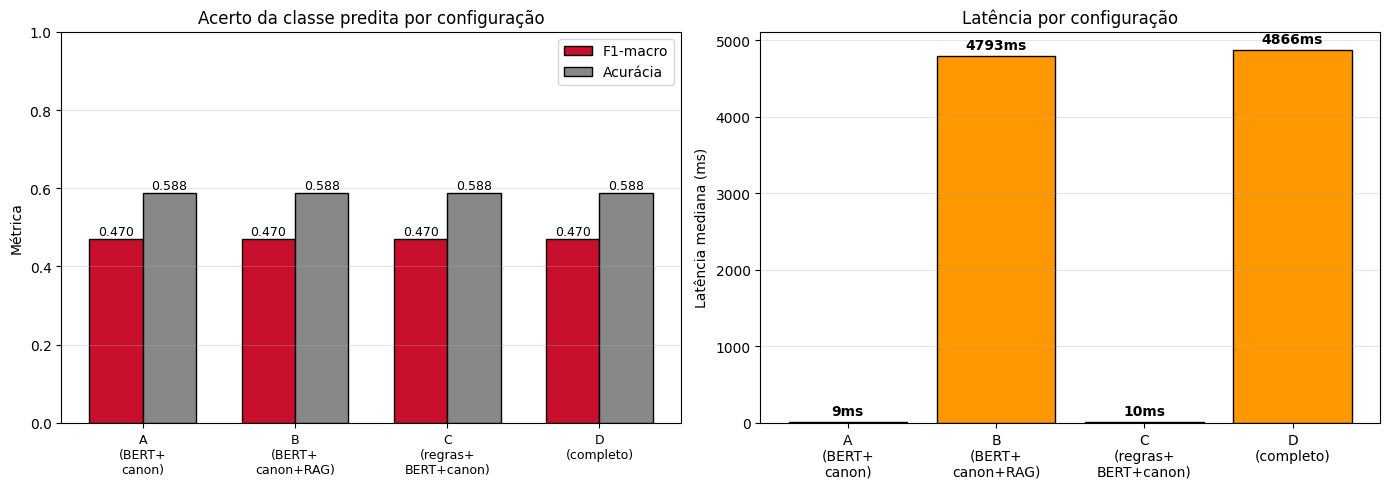

Figura salva: /content/drive/MyDrive/Agente Mecânico/resultados/ablacao_grafico_comparativo.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: F1-macro e acurácia por config
configs_lbl = ['A\n(BERT+\ncanon)', 'B\n(BERT+\ncanon+RAG)', 'C\n(regras+\nBERT+canon)', 'D\n(completo)']
f1_vals  = df_tabela['f1_macro'].tolist()
acc_vals = df_tabela['acuracia'].tolist()

x = np.arange(len(configs_lbl))
w = 0.35
axes[0].bar(x - w/2, f1_vals,  w, label='F1-macro', color='#C8102E', edgecolor='black')
axes[0].bar(x + w/2, acc_vals, w, label='Acurácia', color='#888888', edgecolor='black')
for i, (f1, ac) in enumerate(zip(f1_vals, acc_vals)):
    axes[0].text(i - w/2, f1 + 0.01, f'{f1:.3f}', ha='center', fontsize=9)
    axes[0].text(i + w/2, ac + 0.01, f'{ac:.3f}', ha='center', fontsize=9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(configs_lbl, fontsize=9)
axes[0].set_ylabel('Métrica')
axes[0].set_title('Acerto da classe predita por configuração')
axes[0].set_ylim(0, 1.0)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Subplot 2: latência mediana por config
lat_vals = df_tabela['latencia_ms_mediana'].tolist()
cores_lat = ['#4CAF50','#FF9800','#4CAF50','#FF9800']  # verde se sem LLM, laranja se com
axes[1].bar(configs_lbl, lat_vals, color=cores_lat, edgecolor='black')
for i, v in enumerate(lat_vals):
    axes[1].text(i, v + max(lat_vals)*0.02, f'{v:.0f}ms', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Latência mediana (ms)')
axes[1].set_title('Latência por configuração')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
caminho = RESULTADOS_DIR / 'ablacao_grafico_comparativo.png'
plt.savefig(caminho, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura salva: {caminho}')

---
## Seção 7 — Análise qualitativa de erros e divergências

Identifica relatos onde as configurações divergiram entre si — esses são os casos interessantes.

In [ ]:
# Pivot: por relato, qual classe cada config predisse?
pivot = df_results.pivot_table(
    index=['relato_id', 'relato', 'classe_real'],
    columns='config',
    values='classe_predita',
    aggfunc='first',
).reset_index()

# Achar relatos onde A, B, C, D NÃO concordaram entre si
def divergiu(row):
    preds = [row.get(c) for c in ['A', 'B', 'C', 'D'] if pd.notna(row.get(c))]
    return len(set(preds)) > 1

pivot['divergiu'] = pivot.apply(divergiu, axis=1)
casos_divergentes = pivot[pivot['divergiu']]

print(f'Relatos com divergência entre configs: {len(casos_divergentes)} de {len(pivot)}')
print()

if len(casos_divergentes) > 0:
    print('CASOS DIVERGENTES (até 8):')
    print('='*80)
    for _, row in casos_divergentes.head(8).iterrows():
        print(f'\nRelato: "{row["relato"][:90]}..."')
        print(f'  Real: {int(row["classe_real"])} ({CLASSES[int(row["classe_real"])][:30]})')
        for c in ['A', 'B', 'C', 'D']:
            v = row.get(c)
            if pd.notna(v):
                marca = '✓' if int(v) == int(row['classe_real']) else '✗'
                print(f'  {c}: {int(v)} ({CLASSES.get(int(v),"?")[:30]}) {marca}')

casos_divergentes.to_csv(RESULTADOS_DIR / 'ablacao_casos_divergentes.csv', index=False)

Relatos com divergência entre configs: 0 de 17



In [ ]:
# Análise por variação linguística
if 'variacao_linguistica' in df_results.columns:
    print('\nF1-macro por variação linguística e config:')
    print('='*60)
    for var in df_results['variacao_linguistica'].unique():
        if pd.isna(var): continue
        sub_var = df_results[df_results['variacao_linguistica'] == var]
        n = len(sub_var) // 4  # cada relato aparece 4x (uma por config)
        if n < 2: continue
        print(f'\n  {var} (n={n}):')
        for c in ['A','B','C','D']:
            sub = sub_var[sub_var['config']==c]
            if len(sub) == 0: continue
            y_t = sub['classe_real'].astype(int).values
            y_p = sub['classe_predita'].fillna(-1).astype(int).values
            f1 = f1_score(y_t, y_p, average='macro', labels=list(range(N_CLASSES)), zero_division=0)
            print(f'    {c}: F1={f1:.3f}')


F1-macro por variação linguística e config:

  formal (n=9):
    A: F1=0.217
    B: F1=0.217
    C: F1=0.217
    D: F1=0.217

  giria (n=3):
    A: F1=0.167
    B: F1=0.167
    C: F1=0.167
    D: F1=0.167

  informal (n=5):
    A: F1=0.500
    B: F1=0.500
    C: F1=0.500
    D: F1=0.500


---
## Seção 8 — Sumário do experimento

In [ ]:
print('EXPERIMENTO DE ABLAÇÃO CONCLUÍDO')
print('='*70)
print(f'\nRelatos avaliados: {len(df_teste)}')
print(f'Configurações:     4 (A, B, C, D)')
print(f'Avaliações totais: {len(df_results)}')
print()
print('Melhor configuração por acurácia:')
melhor = df_tabela.loc[df_tabela['acuracia'].idxmax()]
print(f'  Config {melhor["config"]} — acc={melhor["acuracia"]:.3f}, F1={melhor["f1_macro"]:.3f}')
print()
print('Melhor configuração por latência:')
mais_rapida = df_tabela.loc[df_tabela['latencia_ms_mediana'].idxmin()]
print(f'  Config {mais_rapida["config"]} — {mais_rapida["latencia_ms_mediana"]:.0f}ms (mediana)')
print()
print('Artefatos gerados em', RESULTADOS_DIR, ':')
for nome in ['ablacao_tabela_comparativa.csv',
             'ablacao_resultados_brutos.csv',
             'ablacao_casos_divergentes.csv',
             'ablacao_grafico_comparativo.png']:
    print(f'  • {nome}')

EXPERIMENTO DE ABLAÇÃO CONCLUÍDO

Relatos avaliados: 17
Configurações:     4 (A, B, C, D)
Avaliações totais: 68

Melhor configuração por acurácia:
  Config A — acc=0.588, F1=0.470

Melhor configuração por latência:
  Config A — 9ms (mediana)

Artefatos gerados em /content/drive/MyDrive/Agente Mecânico/resultados :
  • ablacao_tabela_comparativa.csv
  • ablacao_resultados_brutos.csv
  • ablacao_casos_divergentes.csv
  • ablacao_grafico_comparativo.png
